In [21]:
import requests
import matplotlib.pyplot as plt
import numpy as np
from typing import Literal
from datetime import datetime, timedelta, timezone as tz
from urllib.parse import urlencode

P = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50]
LOW_CLOUD_HEIGHT = 2500
HIGH_CLOUD_HEIGHT = 6000

In [22]:
def get_point_forecast(lat,lng,time,model,timezone=8,time_select_strategy: Literal["nearest", "linear_interp"] = "linear_interp"):
    def to_timestamp(_time):
        return datetime.strptime(_time, "%Y-%m-%dT%H:%M").replace(tzinfo=tz(timedelta(hours=timezone)))

    baseurl = "https://api.open-meteo.com/v1/forecast"
    param = {
        "latitude": lat,
        "longitude": lng,
        "timezone": f"Etc/GMT{f'-{timezone}' if timezone > 0 else f'+{-timezone}'}",
        "forecast_days": 3,
        "models": model
    }
    dataset = [
        *[f"geopotential_height_{_p}hPa" for _p in P],
        *[f"cloud_cover_{_p}hPa" for _p in P],
    ]
    param["hourly"] = ",".join(dataset)

    final_url = f"{baseurl}?{urlencode(param)}"

    resp = requests.get(final_url)
    data = resp.json()
    # print(data["timezone"])
    if time_select_strategy == "nearest":
        query_time = to_timestamp(time)
        if query_time < to_timestamp(data["hourly"]['time'][0]) or query_time > to_timestamp(data["hourly"]['time'][-1]):
            return None, None
        min_time = -1
        min_time_idx = -1
        for number_time, _time in enumerate(data["hourly"]['time']):
            timestamp = to_timestamp(_time)
            if min_time == -1 or abs(timestamp - query_time) < min_time:
                min_time = abs(timestamp - query_time)
                min_time_idx = number_time
        
        return {
            pname: data["hourly"][pname][min_time_idx] for pname in data["hourly"]
        }, data["hourly"]['time'][min_time_idx]
    elif time_select_strategy == "linear_interp":
        query_time = to_timestamp(time)
        if query_time < to_timestamp(data["hourly"]['time'][0]) or query_time > to_timestamp(data["hourly"]['time'][-1]):
            return None, None
        upper_time_idx = -1
        for number_time, _time in enumerate(data["hourly"]['time']):
            timestamp = to_timestamp(_time)
            if timestamp == query_time:
                return {
                    pname: data["hourly"][pname][number_time] for pname in data["hourly"]
                }, _time
            if timestamp > query_time:
                upper_time_idx = number_time
                break
        t1 = to_timestamp(data["hourly"]['time'][upper_time_idx - 1])
        t2 = to_timestamp(data["hourly"]['time'][upper_time_idx])
        ratio = (query_time - t1) / (t2 - t1)
        result = {}
        for pname in data["hourly"]:
            v1 = data["hourly"][pname][upper_time_idx - 1]
            v2 = data["hourly"][pname][upper_time_idx]
            if pname == "time":
                v1 = to_timestamp(v1)
                v2 = to_timestamp(v2)
                v = v1 + (v2 - v1) * ratio
                result[pname] = v.strftime("%Y-%m-%dT%H:%M")
            else:
                result[pname] = v1 + (v2 - v1) * ratio
        return result, time

def seperate_cloud(data, sep_cover_rate_threshold=0):
    cc_data = [data[f"cloud_cover_{p}hPa"] for p in P]
    h_data = [data[f"geopotential_height_{p}hPa"] for p in P]
    cloud_bottom_height = -1
    result = []
    for i, cc in enumerate(cc_data):
        if cc > sep_cover_rate_threshold:
            if cloud_bottom_height == -1:
                cloud_bottom_height = h_data[i]
        else:
            if cloud_bottom_height != -1:
                result.append((cloud_bottom_height, h_data[i - 1]))
                cloud_bottom_height = -1
    if cloud_bottom_height != -1:
        result.append((cloud_bottom_height, h_data[-1]))
    return result 

# main_cloud_rate_to_max_cc: cc >= m * 最大cc
# skip_low_clouds_threshold: cc < s，也就是允许的最大低云覆盖率，设置0则不跳过低云
def find_main_cloud_bottom(data, main_cloud_rate_to_max_cc=0.4, skip_low_clouds_threshold=0.3):
    cc_data = [data[f"cloud_cover_{p}hPa"] for p in P]
    h_data = [data[f"geopotential_height_{p}hPa"] for p in P]
    max_cc = max(cc_data)
    main_cover_rate = main_cloud_rate_to_max_cc * max_cc
    skip_low_clouds = skip_low_clouds_threshold * 100
    for i, cc in enumerate(cc_data):
        if cc >= main_cover_rate:
            if h_data[i] < LOW_CLOUD_HEIGHT and cc < skip_low_clouds:
                continue
            if cc == 0:
                continue
            return h_data[i], cc
    # 返回最高的低云
    for i, cc in enumerate(reversed(cc_data)):
        if cc >= main_cover_rate:
            return h_data[-i-1], cc
    return 0
    
            

In [23]:
lat = 30.260790137678466
lng = 120.11723778288173

# lat = 29.15628391470641
# lng = 116.67806625366212


model = "ecmwf_ifs025"
# model = "gfs_global"
time = "2026-08-08T05:00"
data, result_time = get_point_forecast(lat, lng, time, model, time_select_strategy="linear_interp")
print(data)
print(result_time)
find_main_cloud_bottom(data)

{'time': '2026-08-08T05:00', 'geopotential_height_1000hPa': 11.0, 'geopotential_height_925hPa': 698.0, 'geopotential_height_850hPa': 1435.0, 'geopotential_height_700hPa': 3088.0, 'geopotential_height_600hPa': 4363.0, 'geopotential_height_500hPa': 5828.0, 'geopotential_height_400hPa': 7561.73, 'geopotential_height_300hPa': 9704.84, 'geopotential_height_250hPa': 11005.72, 'geopotential_height_200hPa': 12537.21, 'geopotential_height_150hPa': 14405.97, 'geopotential_height_100hPa': 16833.33, 'geopotential_height_50hPa': 20958.62, 'cloud_cover_1000hPa': 0, 'cloud_cover_925hPa': 36, 'cloud_cover_850hPa': 16, 'cloud_cover_700hPa': 0, 'cloud_cover_600hPa': 0, 'cloud_cover_500hPa': 0, 'cloud_cover_400hPa': 53, 'cloud_cover_300hPa': 0, 'cloud_cover_250hPa': 0, 'cloud_cover_200hPa': 0, 'cloud_cover_150hPa': 56, 'cloud_cover_100hPa': 0, 'cloud_cover_50hPa': 0}
2026-08-08T05:00


(698.0, 36)

2026-08-08T05:00


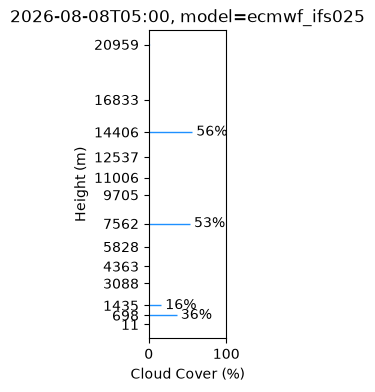

In [24]:
print(data['time'])
height = [
    data[f"geopotential_height_{_p}hPa"] for _p in P
]
cloud = [
    data[f"cloud_cover_{_p}hPa"] for _p in P
]

fig, ax = plt.subplots(figsize=(1, 4))
bars = ax.barh(height, np.array(cloud), height=0.8, color="skyblue", edgecolor="dodgerblue")

c_labels = []
for x in cloud:
    if x == 0:
        c_labels.append("")
    else:
        c_labels.append(f"{x}%")

ax.set_yticks(height)

ax.set_title(f"{data['time']}, model={model}")
ax.set_xlabel("Cloud Cover (%)")
ax.bar_label(bars, labels=c_labels,padding=3)
ax.set_ylabel("Height (m)")
ax.set_xlim(0,100)
plt.show()
